In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_json("run_report.json")
data = data[814:]
# Set device_count to 0 for the first 300 rows
data.loc[data.index[:300], "device_count"] = 0
data = data[data["device_count"] <= 1]

print(data["device_count"].value_counts())

data

In [ ]:
# Aggregate mean and standard deviation of runtime by prompt length and device count
stats = (
    data.groupby(["prompt_length", "device_count"], as_index=False)["time"]
        .agg(mean="mean", std="std")
)
stats["std"] = stats["std"].fillna(0.0)

plt.style.use("bmh")
lengths = list(stats["prompt_length"].unique())
cmap = plt.get_cmap("tab10")
markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]
xticks = sorted(stats["device_count"].unique())

for i, length in enumerate(lengths):
    grp = stats[stats["prompt_length"] == length].sort_values("device_count")
    color = cmap(i % 10)
    fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    ax.plot(
        grp["device_count"], grp["mean"],
        color=color, marker=markers[i % len(markers)],
        linewidth=2, markersize=6, label=f"Prompt length {length}",
    )
    ax.fill_between(
        grp["device_count"],
        grp["mean"] - grp["std"],
        grp["mean"] + grp["std"],
        color=color, alpha=0.18, linewidth=0,
    )
    ax.set_xticks(xticks)
    ax.set_xlim(min(xticks) - 0.25, max(xticks) + 0.25)
    ax.set_xlabel("Device count")
    ax.set_ylabel("Runtime (s)")
    ax.set_title(f"Runtime by device count (Prompt length: {length})")
    ax.grid(which="major", alpha=0.35)
    ax.minorticks_on()
    ax.grid(which="minor", alpha=0.15, linestyle="--")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=True, fancybox=True, framealpha=0.9)
    plt.show()


In [ ]:

# Dot-plot of individual runs: time vs. device_count, colored by prompt length with slight jitter
lengths = list(stats["prompt_length"].unique())
offsets = np.linspace(-0.22, 0.22, num=len(lengths))
jitter = 0.05

fig2, ax2 = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

for idx, length in enumerate(lengths):
    d = data[data["prompt_length"] == length]
    rng = np.random.default_rng(100 + idx)
    x = d["device_count"].to_numpy(dtype=float) + offsets[idx] + rng.uniform(-jitter, jitter, size=len(d))
    ax2.scatter(
        x, d["time"],
        s=22, alpha=0.65,
        color=cmap(idx % 10),
        marker=markers[idx % len(markers)],
        edgecolor="white", linewidth=0.4,
        label=length,
    )

ax2.set_xticks(xticks)
ax2.set_xlim(min(xticks) - 0.5, max(xticks) + 0.5)
ax2.set_xlabel("Device count")
ax2.set_ylabel("Runtime (s)")
ax2.set_title("Runtime dot-plot by device count and prompt length")

ax2.grid(which="major", alpha=0.35)
ax2.minorticks_on()
ax2.grid(which="minor", alpha=0.15, linestyle="--")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

ax2.legend(title="Prompt Length", frameon=True, fancybox=True, framealpha=0.9)
plt.show()

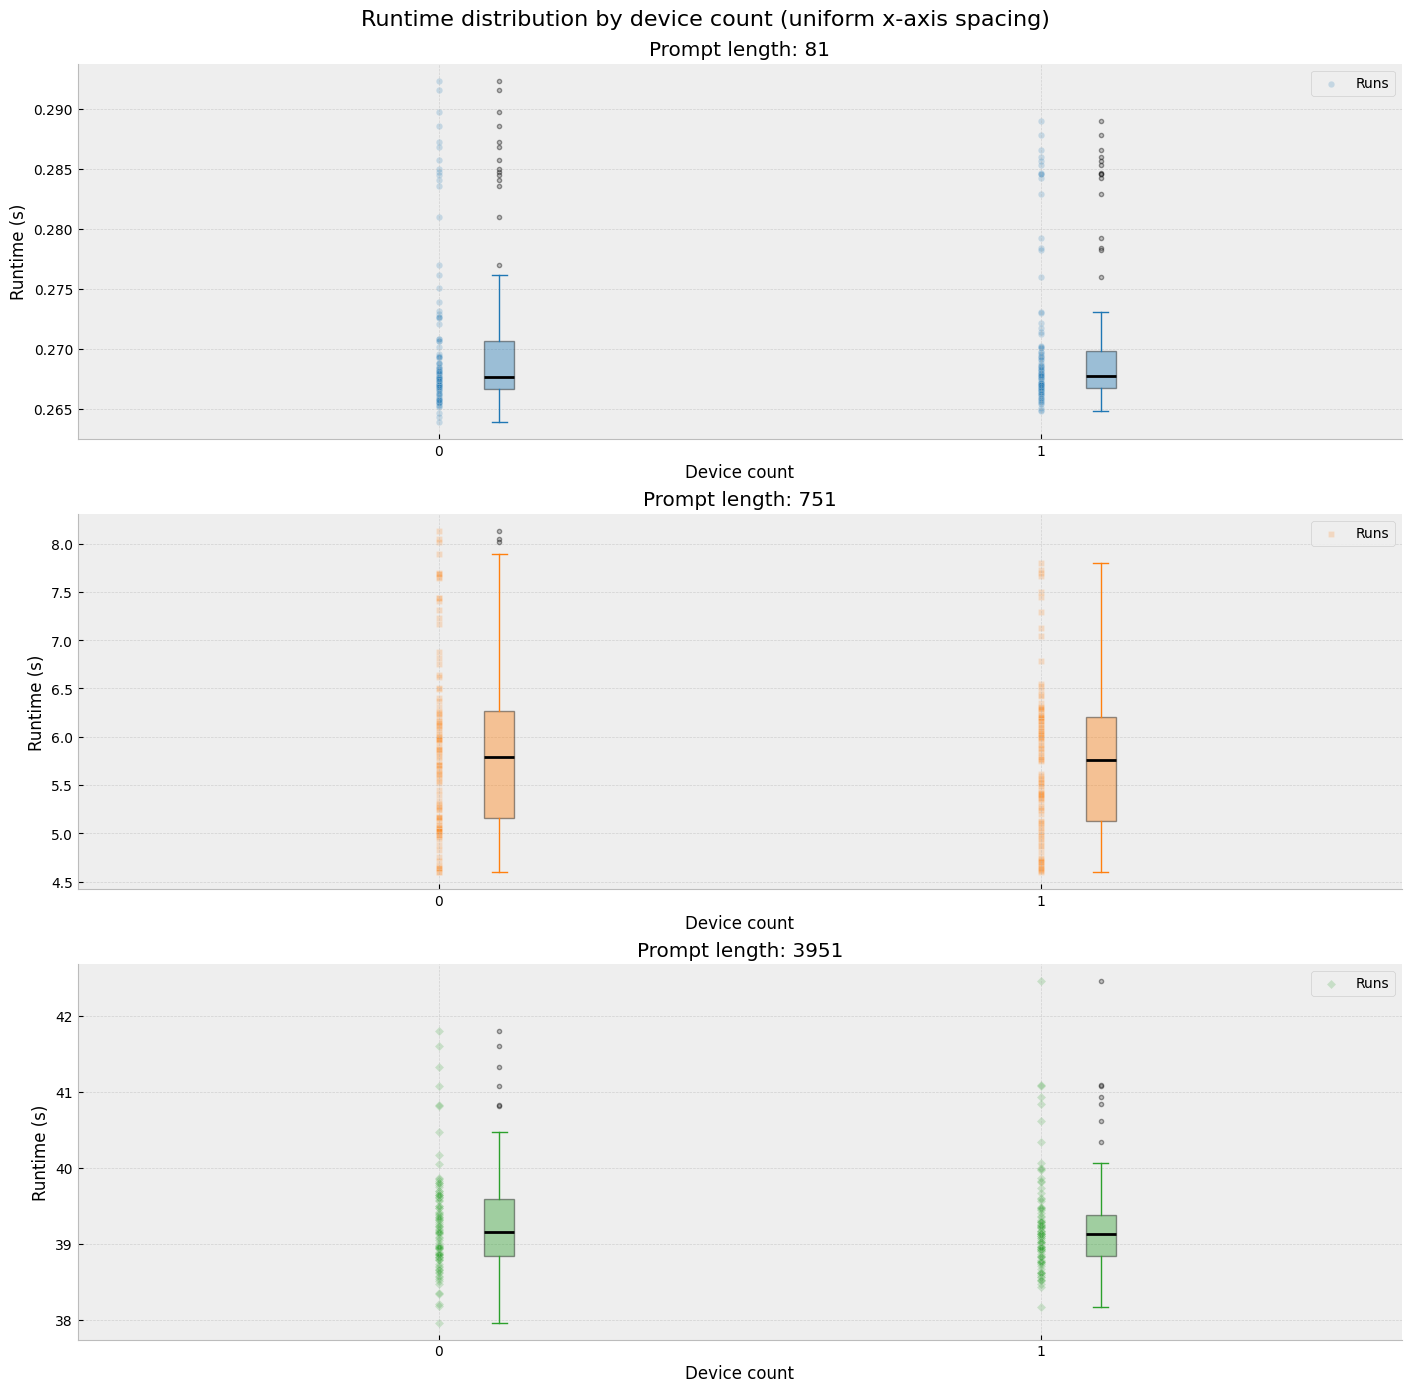

In [15]:
# Map device_count to uniform positions
uniform_positions = {dc: i for i, dc in enumerate(xticks)}

plt.style.use("bmh")
lengths = list(stats["prompt_length"].unique())
colors = [cmap(i % 10) for i in range(len(lengths))]

nrows = int(len(lengths))
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 4.5 * nrows), constrained_layout=True)
axes = axes.flatten() if len(lengths) > 1 else [axes]

for idx, length in enumerate(lengths):
    ax = axes[idx]
    d = data[data["prompt_length"] == length]
    # Map device_count to uniform positions
    x = d["device_count"].map(uniform_positions)
    ax.scatter(
        x,
        d["time"],
        s=22,
        alpha=0.2,
        color=colors[idx],
        marker=markers[idx % len(markers)],
        edgecolor="white",
        linewidth=0.4,
        label="Runs",
    )

    positions = sorted(d["device_count"].unique())
    xd = [d.loc[d["device_count"] == dc, "time"] for dc in positions]
    box_positions = [uniform_positions[p] + 0.1 for p in positions]

    bp = ax.boxplot(
        xd,
        positions=box_positions,
        widths=0.05,
        patch_artist=True,
        boxprops=dict(facecolor=colors[idx], alpha=0.4),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color=colors[idx]),
        capprops=dict(color=colors[idx]),
        flierprops=dict(marker="o", markerfacecolor="gray", alpha=0.4, markersize=3),
    )

    ax.set_xticks(list(uniform_positions.values()))
    ax.set_xticklabels([str(int(p)) for p in xticks])
    ax.set_xlim(-0.6, len(xticks) - 0.4)
    ax.set_xlabel("Device count")
    ax.set_ylabel("Runtime (s)")
    ax.set_title(f"Prompt length: {length}")
    ax.grid(which="major", alpha=0.5)
    ax.minorticks_off()
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=True, fancybox=True, framealpha=0.9, loc="best")

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Runtime distribution by device count (uniform x-axis spacing)", fontsize=16, y=1.02)
plt.show()
